# Compute the vertical profile of a global statistic

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/home/b/b384080/.conda/envs/eekenv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## 0) define functions

In [2]:
def get_thickness(da,mgrab,varia,run,freq_input):
    if model == 'GISSE2.1-G-CC2':
        domain = mgrab.get_domain(varia,freq_input,run)
    else:
        domain = mgrab.get_domain(varia,freq_input)
    print(domain)
    print(da.dims)
    if domain in ['O','OP','OB','ocn']:
        if "lev" in da.dims:
            da = da.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
        elif "olevel" in da.dims:
            da = da.chunk({"time": 12,"olevel": -1})#,"i": -1,"j": -1})
        elif "z_t" in da.dims:
            da = da.chunk({"time": 12,"z_t": -1})#,"i": -1,"j": -1})

        print('... get thickness weights')
        if model == 'NorESM2-LM':
            thickness_weights = mgrab.get_thickness(
                'thkcello',freq_input)
            thickness_weights = thickness_weights.chunk({"lev": -1})#,"i": -1,"j": -1})
        elif model == 'GFDL-ESM2M':
            thickness_weights = mgrab.get_data(
                'thkcello',run,freq_input=freq_input, verbose_level=0)
            thickness_weights = thickness_weights.chunk({"time": 12, "olevel": -1})#,"i": -1,"j": -1})
            thickness_weights = TimeOperator.shift_time_axis_by_n_years(thickness_weights,n=0)
        elif model == 'CESM2':
            thickness_weights = mgrab.get_dz(run,freq_input='monthly',method='precise',verbose_level=1)
        else:
            thickness_weights = mgrab.get_data(
                'thkcello', run, freq_input=freq_input, verbose_level=0)
            thickness_weights = thickness_weights.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
        #print(thickness_weights)
    elif domain in ['A']:
        da = da.chunk({"time": 12,"plev": -1})#,"i": -1,"j": -1})
        plev = da["plev"]  # [plev], in Pa
        # Step 1: layer thickness from differences
        dp = np.abs(plev.diff(dim="plev"))
        # Step 2: append last value (reuse last plev)
        last_plev = plev.isel(plev=-1)
        dp = xr.concat([dp, last_plev], dim="plev")
        # Step 3: fix coordinate alignment
        thickness_weights = dp.assign_coords(plev=plev)
    return thickness_weights

def calc_horizontal_stat(da, mgrab,varia,run,freq_input, area_weights, stat, mask=None, dims=None,thickness_weights=None,grid_cell_fractions=None):        
    if stat == 'mean':
        da_stat = SpaceOperator.calc_spatial_mean(da, area_weights, mask=mask, dims=dims, thickness_weights=thickness_weights, grid_cell_fractions=grid_cell_fractions)
    elif stat == 'integral':
        da_stat = SpaceOperator.calc_spatial_integral(da, area_weights, mask=mask, dims=dims, thickness_weights=thickness_weights, grid_cell_fractions=grid_cell_fractions)
    return da_stat

def get_stat(varia,model):

    # default settings
    if varia in ['dissic','o2','thetao','so','no3']:
        stat = 'mean'
    else:
        raise Exception('statistic not yet defined for this variable.')
    
    #if varia in ['tas','tos','chlos','co2s','co2']:
    #    stat = 'mean'
    #elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cSoilFast','cSoilMedium','cSoilSlow','cVeg','cCwd','cLitter','dissic','fco2antt','intdic','epc100']:
    #    stat = 'integral'
    #elif varia in ['co2mass']:
    #    stat = None

    ## overwrite some choices
    #if model == 'GISSE2.1-G-CC2':
    #    if varia == 'co2mass':
    #        stat = 'integral'
    
    return stat

## 1) get the varias, models and runs over which to do computation

In [3]:
#stat = 'integral'#'mean'
freq_input = 'monthly'#'monthly'#'yearly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['dissic']#['no3','so']#['dissic','thetao','so','no3','o2'] #'o2']#['thetao']#['intpp','intdic']#['tos','fgco2']#['tas','npp','nbp','cSoil','cVeg','cLand','co2mass','intdic','intpp','tos','fgco2'] #'co2mass']#,'fco2antt']#,'intdic'] #['dissic']#['intpp','npp','tas','tos','fgco2','nbp','fco2antt','cLand','cVeg','cSoil','npp','co2mass',]#['co2']#['co2mass']#['cSoilFast','cSoilMedium','cSoilSlow']#['epc100','cLand','cVeg','nbp','intpp','npp']#,'fgco2',''epc100']#['epc100','fgco2','intpp','tos']#['npp','cSoil','cLand','cVeg']#['fgco2','tas']#['epc100']#['fgco2','intpp','npp','cLand']#['co2s']#['intpp','chlos','epc100']#['cLand','cVeg','cSoil','npp','co2mass','tas','tos','fgco2','nbp','fco2antt','intpp','npp','cLand','cVeg','cSoil','intdic']#['npp','cLand','fgco2','nbp','fco2antt']#'fco2antt']#['tas','nbp','fgco2','fco2antt','co2mass','tos','npp']#]#['intpp','npp','tos'] # ['fgco2','nbp','cLand','dissic','cSoil','cVeg','cLitter','cCwd']#  # 'tas',                ,'co2mass']#['fgco2']#['nbp']#['nbp','cLand'] #['nbp']#['nbp']#['fco2antt']#['cLand','cSoil','cVeg','cLitter','cCwd']#['cLitter']#'cCwd',#['cLand']#['cSoil','cVeg']#['cLitter']#['cCwd']#['cSoil','cVeg']#'cLand',#['tas','nbp','npp','tos','fgco2','intpp']
models = ['CESM2']#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1'] #['CESM2']#['NorESM2-LM'] #['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']# ['CESM2']#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1'] #['IPSL-CM6-ESMCO2']#['GFDL-ESM2M']#['CESM2']#['UKESM1-2']#['EC-Earth3-ESM-1']#['GISSE2.1-G-CC2']#['UKESM1-2']#['GISSE2.1-G-CC2']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']##['GISSE2.1-G-CC2']#['CESM2']#['ACCESS-ESM1-5'] #['ACCESS-ESM1-5']#['IPSL-CM6-ESMCO2']#['NorESM2-LM']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M']#['MIROC-ES2L'] ['IPSL-CM6-ESMCO2']#['EC-Earth3-ESM-1']#['UKESM1-2']#['IPSL-CM6-ESMCO2']#['IPSL-CM6-ESMCO2']#[]#['GISSE2.1-G-CC2']#['EC-Earth3-ESM-1']#,'UKESM1-2']#['NorESM2-LM']#['GFDL-ESM2M']#['IPSL-CM6-ESMCO2']#['UKESM1-2']#['IPSL-CM6-ESMCO2','NorESM2-LM','GFDL-ESM2M'] # ,
runs = pruns.get_run_list('tipmip_tier1')#[3:]#[-3:-2]#[1:-3]#[-2:]#[-3:-2]#[1:]#[:1]#[:-2]#[1:]#[5:]#[1:2]#[2:]#[-1:]#[:1]#[5:]#[1:]#[:-1]#[:1]#[-1:]#[:1]#[:1]#[1:]#[-1:] #
stat = 'integral' # horizontal_stat
weight_by_thickness = True

#server='spirit'#'levante'#'spirit'#
outroot = './../01_postprocessed_data/vertical_profiles'

## 2) loop over models and runs to do the computation, plotting and saving

In [4]:
from dask.distributed import Client
client = Client(n_workers=8)
client

server = MISCgrabber.get_server()
if server == 'levante':
    port = client.scheduler_info()["services"]["dashboard"]
    prefix = os.environ.get("JUPYTERHUB_SERVICE_PREFIX", "/")
    proxy_url = f"https://jupyterhub.dkrz.de/{prefix}proxy/{port}/status"
    print(proxy_url)
else:
    print(client)


working on server levante
https://jupyterhub.dkrz.de//user/b384080/levante-spawner-advanced/proxy/8787/status


dissic
DIC
Processing data for DIC, CESM2, esm-piControl...
['/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.DIC.000101-001012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.DIC.001101-002012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.DIC.002101-003012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.DIC.003101-004012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-piControl.001.pop.h.DIC.004101-005012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-piControl.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.es

2026-07-28 22:45:57,655 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 7.92 GiB -- Worker memory limit: 12.50 GiB
2026-07-28 22:45:59,035 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 10.02 GiB -- Worker memory limit: 12.50 GiB
2026-07-28 22:45:59,142 - distributed.worker.memory - WARNING - Worker is at 68% memory usage. Resuming worker. Process memory: 8.52 GiB -- Worker memory limit: 12.50 GiB
2026-07-28 22:46:11,456 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged 

... plotting esm-up2p0-gwl2p0
 
dissic
DIC
Processing data for DIC, CESM2, esm-up2p0-gwl4p0...
['/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001.pop.h.DIC.023101-024012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001.pop.h.DIC.024101-025012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001.pop.h.DIC.025101-026012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001.pop.h.DIC.026101-027012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0.001.pop.h.DIC.027101-028012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.

2026-07-28 22:50:58,240 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 9.38 GiB -- Worker memory limit: 12.50 GiB


... plotting esm-up2p0-gwl4p0
 
dissic
DIC
Processing data for DIC, CESM2, esm-up2p0-gwl2p0-50y-dn2p0...
['/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001.pop.h.DIC.016601-017512.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001.pop.h.DIC.017601-018512.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001.pop.h.DIC.018601-019512.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001.pop.h.DIC.019601-020512.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl2p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-

...

... plotting esm-up2p0-gwl2p0-50y-dn2p0
 
dissic
DIC
Processing data for DIC, CESM2, esm-up2p0-gwl4p0-50y-dn2p0...
['/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001.pop.h.DIC.028101-029012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001.pop.h.DIC.029101-030012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001.pop.h.DIC.030101-031012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001.pop.h.DIC.031101-032012.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f0

2026-07-28 22:55:58,782 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 8.54 GiB -- Worker memory limit: 12.50 GiB
2026-07-28 22:56:19,878 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 8.66 GiB -- Worker memory limit: 12.50 GiB
2026-07-28 22:56:21,984 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. --

... plotting esm-up2p0-gwl4p0-50y-dn2p0
 
dissic
DIC
Processing data for DIC, CESM2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0...
['/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.001.pop.h.DIC.040601-041512.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.001.pop.h.DIC.041601-042512.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.001.pop.h.DIC.042601-043512.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.001/ocn/proc/tseries/month_1/b.e21.B1850.f09_g17.esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0.001.pop.h.DIC.043601-044512.nc', '/work/bm1448/upload/tipesm/CESM2/b.e21.B1850.f09_g17.esm-up2

2026-07-28 23:00:01,852 - distributed.worker.memory - WARNING - Worker is at 81% memory usage. Pausing worker.  Process memory: 10.21 GiB -- Worker memory limit: 12.50 GiB
2026-07-28 23:00:02,069 - distributed.worker.memory - WARNING - Worker is at 70% memory usage. Resuming worker. Process memory: 8.86 GiB -- Worker memory limit: 12.50 GiB
2026-07-28 23:00:59,143 - distributed.worker.memory - WARNING - Unmanaged memory use is high. This may indicate a memory leak or the memory may not be released to the OS; see https://distributed.dask.org/en/latest/worker-memory.html#memory-not-released-back-to-the-os for more information. -- Unmanaged memory: 9.05 GiB -- Worker memory limit: 12.50 GiB


... plotting esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0
 


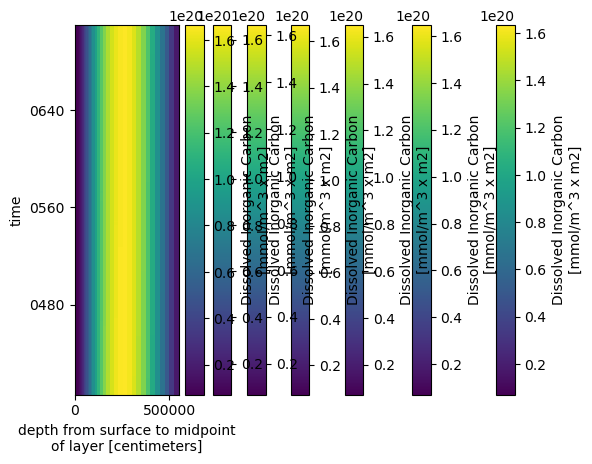

In [6]:
for varia in varias:
    for model in models:
        mgrab = MODELgrabber.get_grabber(model)
        #stat = get_stat(varia,model)

        global_stats = dict()
        for run in runs:

            if model == 'CESM2':
                print(varia)
                varia = mgrab.varia_mapper_cmor_to_model(varia)
                print(varia)

            if model == 'GISSE2.1-G-CC2':
                member = mgrab.get_member(run)
                domain = mgrab.get_domain(varia,freq_input,run)
            else:
                member = mgrab.get_member()
                domain = mgrab.get_domain(varia,freq_input)
        
            print(f'Processing data for {varia}, {model}, {run}...')
            
            # first get the dataset
            da = mgrab.get_data(varia,run,freq_input=freq_input,verbose_level=1)#,server=server)#,server=server)
            
            print(f'... loading {da.time.size} data points in time.')
            print(da)

            if "lev" in da.dims:
                da = da.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
            elif "olevel" in da.dims:
                da = da.chunk({"time": 12,"olevel": -1})#,"i": -1,"j": -1})
            elif "z_t" in da.dims:
                da = da.chunk({"time": 12,"z_t": -1})#,"i": -1,"j": -1})

            #if model == 'CESM2' and varia == 'TEMP':
            #    print('choosing only the shallowest layer')
            #    da = da.isel(z_t=0)#.squeeze().persist()
            #    #print(da)
        
            # =====================================================
            # HORIZONTAL STAT (on correct input)
            # =====================================================
            
            if stat is not None:
                # get the area_weights
                print(f'... getting area weights.')
                if model == 'GISSE2.1-G-CC2':
                    area_weights = mgrab.get_area(varia,freq_input,run)
                else:
                    area_weights = mgrab.get_area(varia,freq_input)
                #area_weights.plot();plt.show()
                #print(area_weights.lat)
                
                # which region do i want to cover
                #print(f'... getting a regional mask.') 
                
                #if varia in ['nbp','cLand']:
                print('getting land area fraction if necessary')
                grid_cell_fractions = mgrab.get_area_fraction(varia)
                #grid_cell_fractions.plot();plt.show()
                #print(grid_cell_fractions.lat)
                #else:
                #    grid_cell_fractions = None

                if weight_by_thickness == True:
                    thickness_weights = get_thickness(da,mgrab,varia,run,freq_input)
                    if "lev" in thickness_weights.dims and "time" in thickness_weights.dims:
                        thickness_weights = thickness_weights.chunk({"time": 12,"lev": -1})#,"i": -1,"j": -1})
                    elif "olevel" in thickness_weights.dims and "time" in thickness_weights.dims:
                        thickness_weights = thickness_weights.chunk({"time": 12,"olevel": -1})#,"i": -1,"j": -1})
                    elif "z_t" in thickness_weights.dims and "time" in thickness_weights.dims:
                        thickness_weights = thickness_weights.chunk({"time": 12,"z_t": -1})#,"i": -1,"j": -1})
                else:
                    thickness_weights = None
                    
                print('... compute horizontal statistic')
                global_stat = calc_horizontal_stat(
                    da,   # <-- key line
                    mgrab,
                    varia,
                    run,
                    freq_input,
                    area_weights,
                    stat,
                    mask=None,
                    dims=None,
                    thickness_weights = thickness_weights,
                    grid_cell_fractions=grid_cell_fractions,
                )
            else:
                grid_cell_fractions = mgrab.get_area_fraction(varia) # not directly used, but required for writing some attributes later on
                global_stat = da_for_horiz

            # make sure that the time has uniform axis
            global_stat = TimeOperator.adjust_time_axis(global_stat) 

            # =====================================================
            # NAMING (clean + consistent)
            # =====================================================
            if model == 'CESM2':
                print(varia)
                varia = mgrab.varia_mapper_model_to_cmor(varia)
                print(varia)

            name_parts = [varia]
            name_parts.append(f"global_{stat}")
            global_stat.name = "_".join(name_parts)
            
            # update the unit
            if stat == 'integral':
                unit = f'{da.units} x m2'  
            elif stat == 'mean':
                unit = f'{da.units}'
            else:
                unit = da.units
            global_stat.attrs["units"] = unit

            if grid_cell_fractions is not None:
                global_stat.attrs["grid_cell_fractions"] = f"Calculating the global {stat} for {varia} scales coastal points by their cell fractions."
            else:
                global_stat.attrs["grid_cell_fractions"] = f"sftlf or sftof are not considered when calculating {varia} {stat}."
            
            # save the data
            save_dir = f'{outroot}/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
            os.makedirs(save_dir,exist_ok=True)
            save_string = f'{save_dir}/{varia}_{model}_{run}_{member}_global_{stat}.nc'
            print(f'... saving under {save_string}')

            global_stat = global_stat.compute()

            #print(global_stat)
            #encoding = {global_stat.name: {"dtype": "float32", "zlib": True, "complevel": 4}}
            global_stat.to_netcdf(save_string, mode="w")#,encoding=encoding)

            # keep in a local dictionary for plotting
            global_stats[run] = global_stat

            #for key in global_stats.keys():
            print(f'... plotting {run}')
            global_stats[run].plot()
            print(' ')

        plt.show()


## Plotting the vertical profiles for the different runs

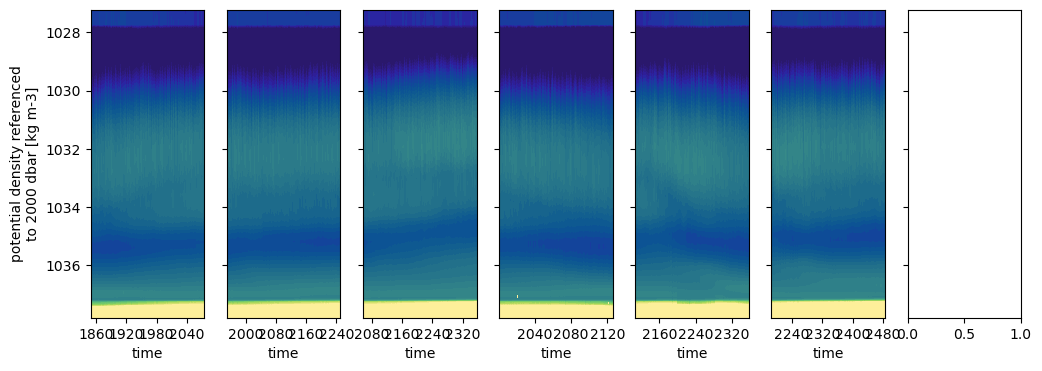

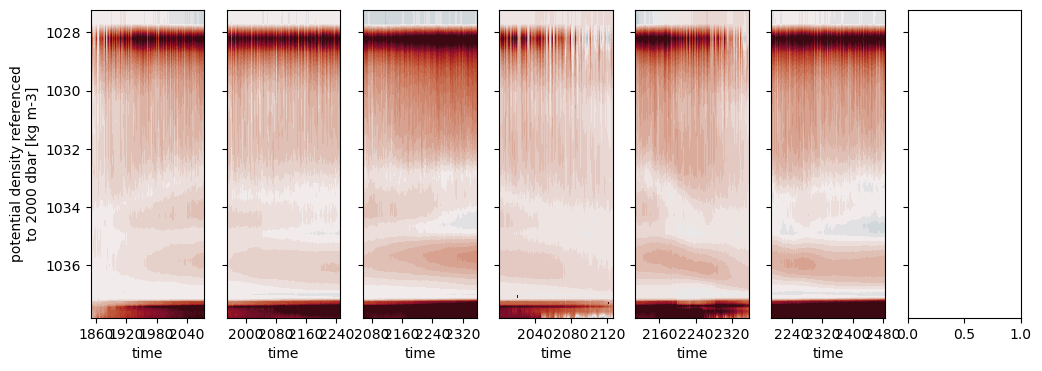

In [11]:
ref_profile = (global_stats['esm-up2p0'].isel(time=slice(0,12)).mean(dim='time'))

fig, ax = plt.subplots(1, 7, figsize=(12, 4),sharey=True)

for kdx,key in enumerate(global_stats.keys()):
    da = global_stats[key].T

    da.plot.contourf(
        ax=ax[kdx],
        x="time",
        y="rho",#"lev", #"z_t", #
        cmap="cmo.haline",
        vmin=34, #0, #2.000,
        vmax=36, #50, #2.500,
        levels=41,
        add_colorbar=False,   # don't make one automatically
    )
for adx,a in enumerate(ax):
    a.invert_yaxis()
    if adx != 0:
        a.set_ylabel('')

plt.show()

fig, ax = plt.subplots(1, 7, figsize=(12, 4),sharey=True)

for kdx,key in enumerate(global_stats.keys()):
    da = (global_stats[key] - ref_profile).T

    da.plot.contourf(
        ax=ax[kdx],
        x="time",
        y="rho",#"lev", #"z_t", #"lev",
        cmap="cmo.balance",
        vmin=-1, #-10,
        vmax=1, #10,
        levels=41,
        add_colorbar=False,   # don't make one automatically
    )
for adx,a in enumerate(ax):
    a.invert_yaxis()
    if adx != 0:
        a.set_ylabel('')

plt.show()